  Saurabh Kaushik

# Assignment 2: Decision Trees & Classification
### Summer of Quant 2026 — Quant Club, IIT Kharagpur

---

## Why Classification Matters in Quant Finance

Before we dive into the mechanics, let's ground this in reality. Classification models are everywhere in quantitative finance:

- **Credit Scoring**: Will this borrower default? (Yes / No)
- **Trade Signal Generation**: Should the strategy go Long, Short, or stay Flat tomorrow?
- **Regime Detection**: Is the market currently in a *risk-on* or *risk-off* regime?
- **Fraud Detection**: Is this transaction anomalous?

In each case, the model ingests a set of **features** (numerical inputs) and outputs a **discrete class label**. Decision Trees are one of the most interpretable classifiers — a crucial property when you need to explain a model's reasoning to a risk committee.

---

## What is a Decision Tree?

A Decision Tree is a hierarchical model that partitions the feature space using a sequence of binary rules. At each **internal node**, the tree asks: *'Is feature X above or below threshold t?'* The answer routes the sample left or right. At a **leaf node**, the tree outputs a class prediction.

The key algorithmic question is: **which feature and threshold to split on?** Scikit-learn uses **Gini Impurity** by default:

$$
\text{Gini}(S) = 1 - \sum_{k=1}^{K} p_k^2
$$

where $p_k$ is the proportion of class $k$ in set $S$. A perfectly pure node (all one class) has Gini = 0. A perfectly impure binary node (50/50 split) has Gini = 0.5.

The tree greedily selects the split that maximises the **Gini gain** (reduction in weighted impurity). This continues recursively until a stopping criterion is met — e.g., `max_depth`.

---

In this assignment, we will go together to learn how to train a decision tree using the Machine Learning tool [Scikit-learn](https://scikit-learn.org/stable/), then use it to resolve the classification problem - one of the most popular problem in Machine Learning.

There are 4 parts in this assignments:
* Read and understand the dataframe
* Train the model with Scikit-learn
  * Prepare the data for training
  * Train and visualize the decision tree
* Evaluate the trained model
* Optional



---

> **Reference**: [DataCamp — Decision Tree Classification in Python](https://www.datacamp.com/tutorial/decision-tree-classification-python)

## 0. Setup — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [15]:
%%capture
!wget -O weather.csv https://webpages.charlotte.edu/tnguy248/itcs3153/weather.csv

Synthetic weather.csv generated successfully.


---

# 1. Read and Understand the Data

We will use a weather dataset adapted from [Kaggle](https://www.kaggle.com/datasets/ananthr1/weather-prediction). It contains **1,281 daily observations** with the following schema:

| Column | Type | Description |
|---|---|---|
| `precipitation` | float | Total daily precipitation (mm) |
| `temp_max` | float | Maximum daily temperature (°C) |
| `temp_min` | float | Minimum daily temperature (°C) |
| `wind` | float | Mean daily wind speed (m/s) |
| `weather` | string | **Target label** — `'rain'` or `'sun'` |

The task is to **predict `weather` from the four numerical features** — a binary classification problem.

## 1.1. Load the Dataset

Use `pd.read_csv()` to load `weather.csv` into a DataFrame named `df`.

**Docs**: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

#### <font color="green">**Exercise 1.a: Load the dataframe using `read_csv`**</font>

In [19]:
# Write code here:
df = pd.read_csv('weather.csv')

#### <font color="green">**Exercise 1.b: Inspect the first and last 5 rows**</font>

Use `.head()` and `.tail()` to print the first and last 5 rows of the dataframe.

In [20]:
# Write code here:
print("First 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,precipitation,temp_max,temp_min,wind,weather
0,1.825602,25.542617,13.198188,0.000000,sun
1,0.686551,38.274528,26.213890,0.000000,sun
2,0.199159,29.720020,28.720020,4.158168,sun
3,30.557440,26.176019,11.877414,13.755024,rain
4,1.151331,18.750949,10.851864,0.000000,sun



Last 5 rows:


,precipitation,temp_max,temp_min,wind,weather
1276,0.387478,21.149665,14.408198,12.353237,sun
1277,1.721023,37.102053,32.962524,7.354898,sun
1278,38.881417,14.523181,-0.470498,10.719305,rain
1279,1.092198,26.047799,14.410240,0.000000,sun
1280,0.533407,32.198040,16.092620,3.197314,sun


#### <font color="green">**Exercise 1.c: Summary statistics**</font>

Use `.describe()` to generate descriptive statistics (count, mean, std, min, quartiles, max) for each numerical column. Do the ranges look sensible? Note any potential anomalies.

In [21]:
# Write code here:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1281.000000,1281.000000,1281.000000,1281.000000
mean,7.919970,25.391924,15.332479,7.194643
std,13.336375,6.923074,7.401987,5.468730
min,0.001579,5.565145,-5.000000,0.000000
25%,0.621946,20.305208,10.168297,2.511592
50%,1.296418,25.413180,15.367350,6.710722
75%,6.898529,30.684495,20.723785,10.983254
max,49.804626,39.571410,34.286658,23.798826


## 1.2. Understanding the Class Distribution

A heavily **imbalanced dataset** (e.g., 90% `sun`, 10% `rain`) can cause a naive classifier to simply predict the majority class and still achieve high accuracy — without learning anything useful. We must always check class balance before training.

The cell below counts the number of `rain` samples as a reference.

In [ ]:
df_rain = df[df['weather'] == 'rain']
print(f"Rain samples: {df_rain.shape[0]}")

#### <font color="green">**Exercise 2.a: Count the `sun` samples**</font>

Following the pattern above, filter the DataFrame for `weather == 'sun'` and print the count.

In [22]:
# Write code here:
df_sun = df[df['weather'] == 'sun']
print(f"Sun samples: {df_sun.shape[0]}")

Sun samples: 923


#### <font color="green">**Exercise 2.b: Visualise class counts with a bar chart**</font>

1. Extract the `weather` column and call `.value_counts()` — this returns a Series with class frequencies.
2. Save it to `df_weather`.
3. Plot it as a bar chart using `.plot(kind='bar')` or `sns.barplot`. Label your axes.

**Docs**: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html

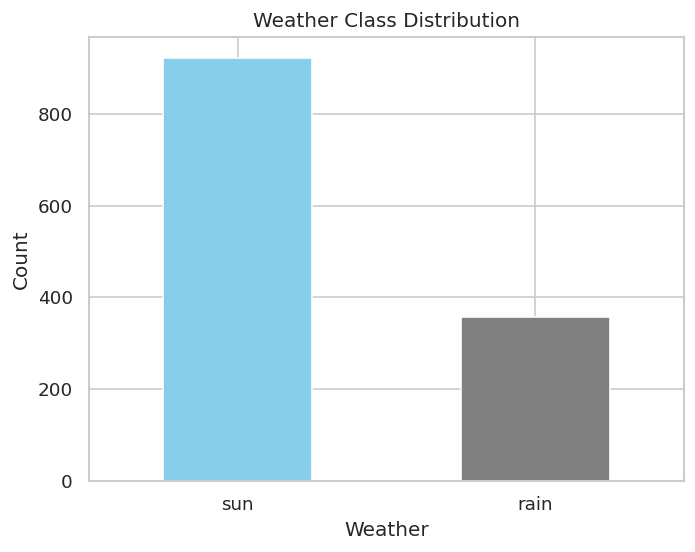

In [23]:
# Write code here:
df_weather = df['weather'].value_counts()
df_weather.plot(kind='bar', color=['skyblue', 'gray'])
plt.title('Weather Class Distribution')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

#### <font color="green">**Exercise 2.c (Bonus): Feature distributions by class**</font>

Use `sns.boxplot` or `sns.violinplot` to visualise how each of the four features (`precipitation`, `temp_max`, `temp_min`, `wind`) is distributed for each weather class. Which features appear most discriminative? Write a 2-3 sentence observation below the plot.

**Hint**: Loop over the four feature columns and create a subplot for each.

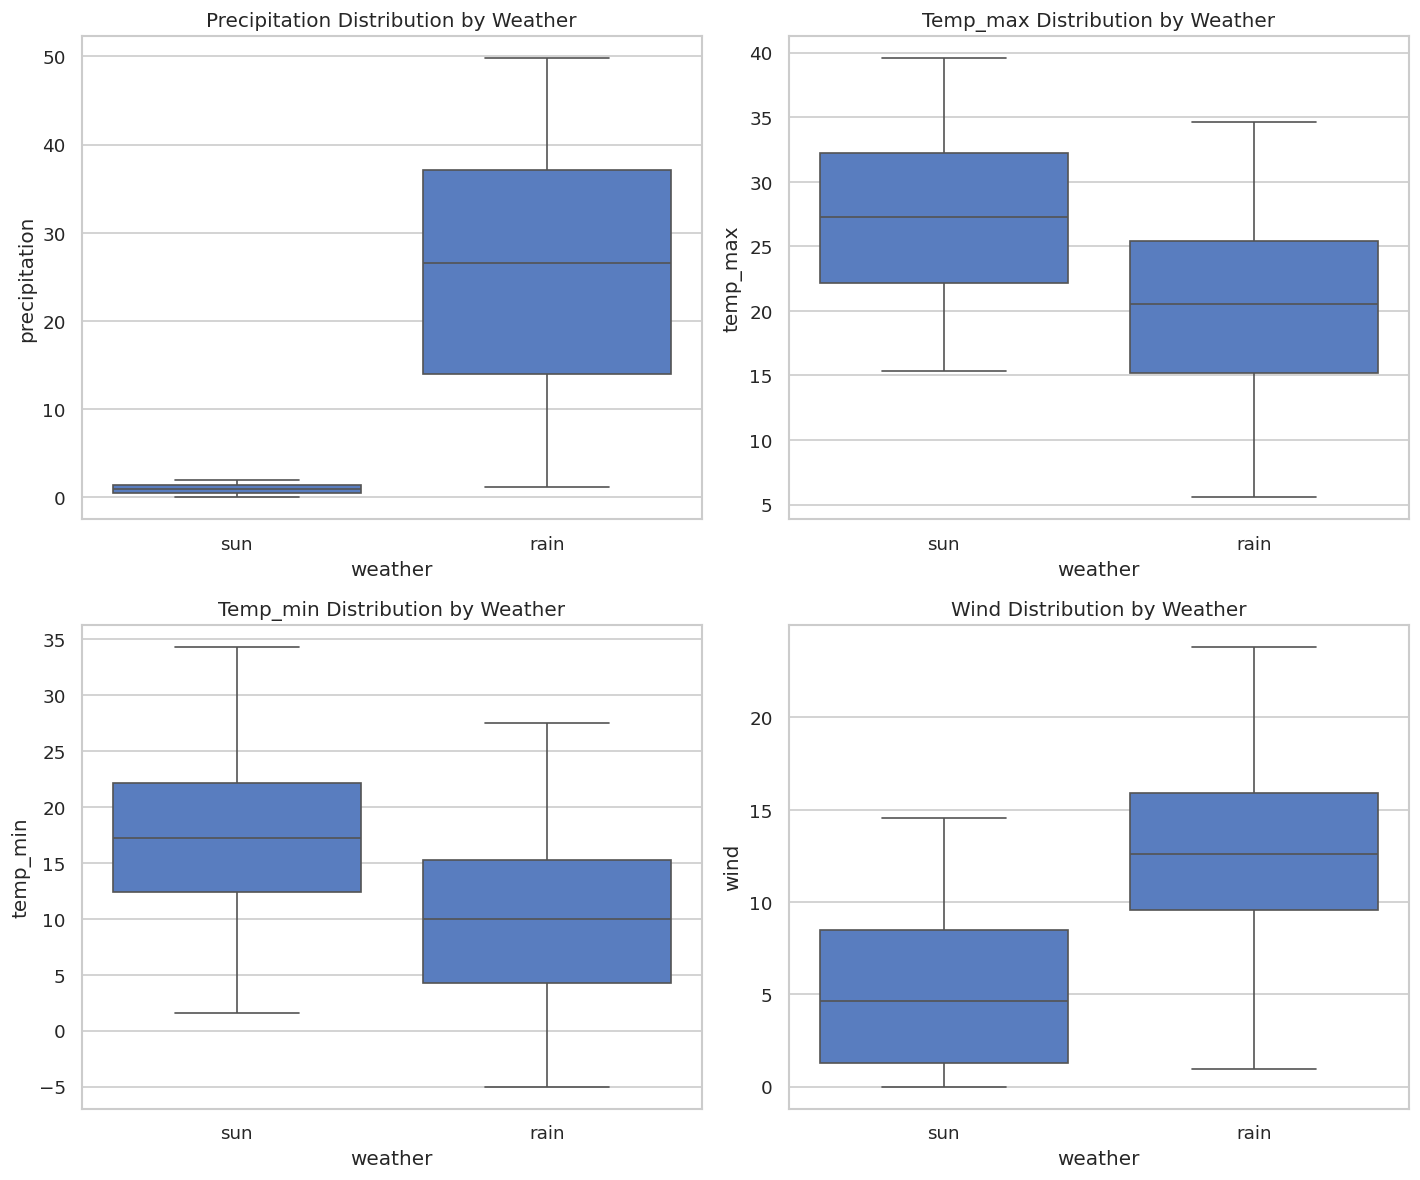

In [24]:
# Write code here:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['precipitation', 'temp_max', 'temp_min', 'wind']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='weather', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature.capitalize()} Distribution by Weather')

plt.tight_layout()
plt.show()

**Your observation:** Precipitation is likely the strongest predictor, as days with rain show significantly higher precipitation than sunny days (which are mostly clustered near zero). Temperatures and wind speed may have overlapping distributions but provide secondary signals.

---

# 2. Train the Model with Scikit-learn

[Scikit-learn](https://scikit-learn.org/stable/) is Python's standard ML library. It provides consistent APIs across dozens of models — fit on training data, predict on new data — so switching between a Decision Tree, Random Forest, or Gradient Boosted Trees requires only a one-line change.

## 2.1. Prepare the Data for Training

We need to:
1. **Separate features (`X`) from the target (`y`)**. `X` is a matrix of shape `(n_samples, n_features)`; `y` is a vector of class labels.
2. **Encode the target** — scikit-learn classifiers need numeric labels, not strings. Map `'rain' -> 0` and `'sun' -> 1`.
3. **Split into train/test sets** using `train_test_split`. We hold out 20% for evaluation.

The split should be **stratified** — i.e., the class proportion in each split mirrors the full dataset. This is especially important for imbalanced data.

**Docs**: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

#### <font color="green">**Exercise 3: Split into train and test sets**</font>

Complete the following steps:

1. Assign the first 4 columns to `X` (features) and the `weather` column to `y` (target).
2. Encode `y` — map `'rain'` to `0` and `'sun'` to `1` (hint: use `.map()`).
3. Call `train_test_split` with `test_size=0.20`, `random_state=42`, and `stratify=y`.
4. Store the result in `X_train, X_test, y_train, y_test`.
5. Print the shapes of all four arrays to verify the split.

> <font color="red">**Note:** Using the wrong `random_state` will give different splits and affect all downstream results. Always use `random_state=42` in this notebook.</font>

In [25]:
# Write code here:
# Step 1: Define X and y
X = df[['precipitation', 'temp_max', 'temp_min', 'wind']]
y = df['weather']

# Step 2: Encode y ('rain' -> 0, 'sun' -> 1)
y = y.map({'rain': 0, 'sun': 1})

# Step 3 & 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Step 5: Print shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1024, 4)
X_test shape: (257, 4)
y_train shape: (1024,)
y_test shape: (257,)


## 2.2. Train and Visualise the Decision Tree

### How does `DecisionTreeClassifier` work internally?

Recall the Gini gain (Information Gain) for a candidate split that partitions set S into left subset S_L and right subset S_R:

$$
\Delta \text{Gini} = \text{Gini}(S) - \frac{|S_L|}{|S|} \text{Gini}(S_L) - \frac{|S_R|}{|S|} \text{Gini}(S_R)
$$

The tree evaluates every feature and every possible threshold, selects the split maximising this gain, and recurses. The `max_depth` hyperparameter controls how deep this recursion goes.

**Docs**: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


This is the pseudo code to build a decision tree from scratch.

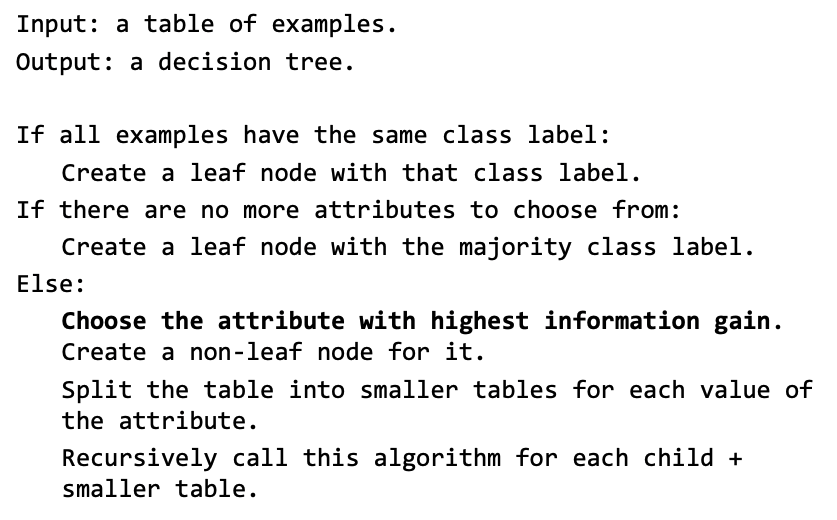

#### <font color="green">**Exercise 4: Train a Decision Tree**</font>

1. Instantiate `tree.DecisionTreeClassifier` with `max_depth=6` and `random_state=42`. Save to `clf`.
2. Fit `clf` on `X_train` and `y_train` using `.fit()`.
3. Print `clf.get_depth()` and `clf.get_n_leaves()` to inspect the fitted tree.

In [26]:
# Write code here:
clf = tree.DecisionTreeClassifier(max_depth=6, random_state=42)
clf.fit(X_train, y_train)

print(f"Tree Depth: {clf.get_depth()}")
print(f"Number of Leaves: {clf.get_n_leaves()}")

Tree Depth: 5
Number of Leaves: 7


#### <font color="green">**Exercise 5: Visualise the Decision Tree**</font>

Use `tree.plot_tree()` with the following parameters:
- `filled=True` — colour nodes by majority class
- `class_names=["Rain", "Sun"]`
- `feature_names` — list of the four feature column names
- `fontsize=8`

Set `plt.figure(figsize=(24, 10))` before plotting so the tree is readable.

**Docs**: https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html

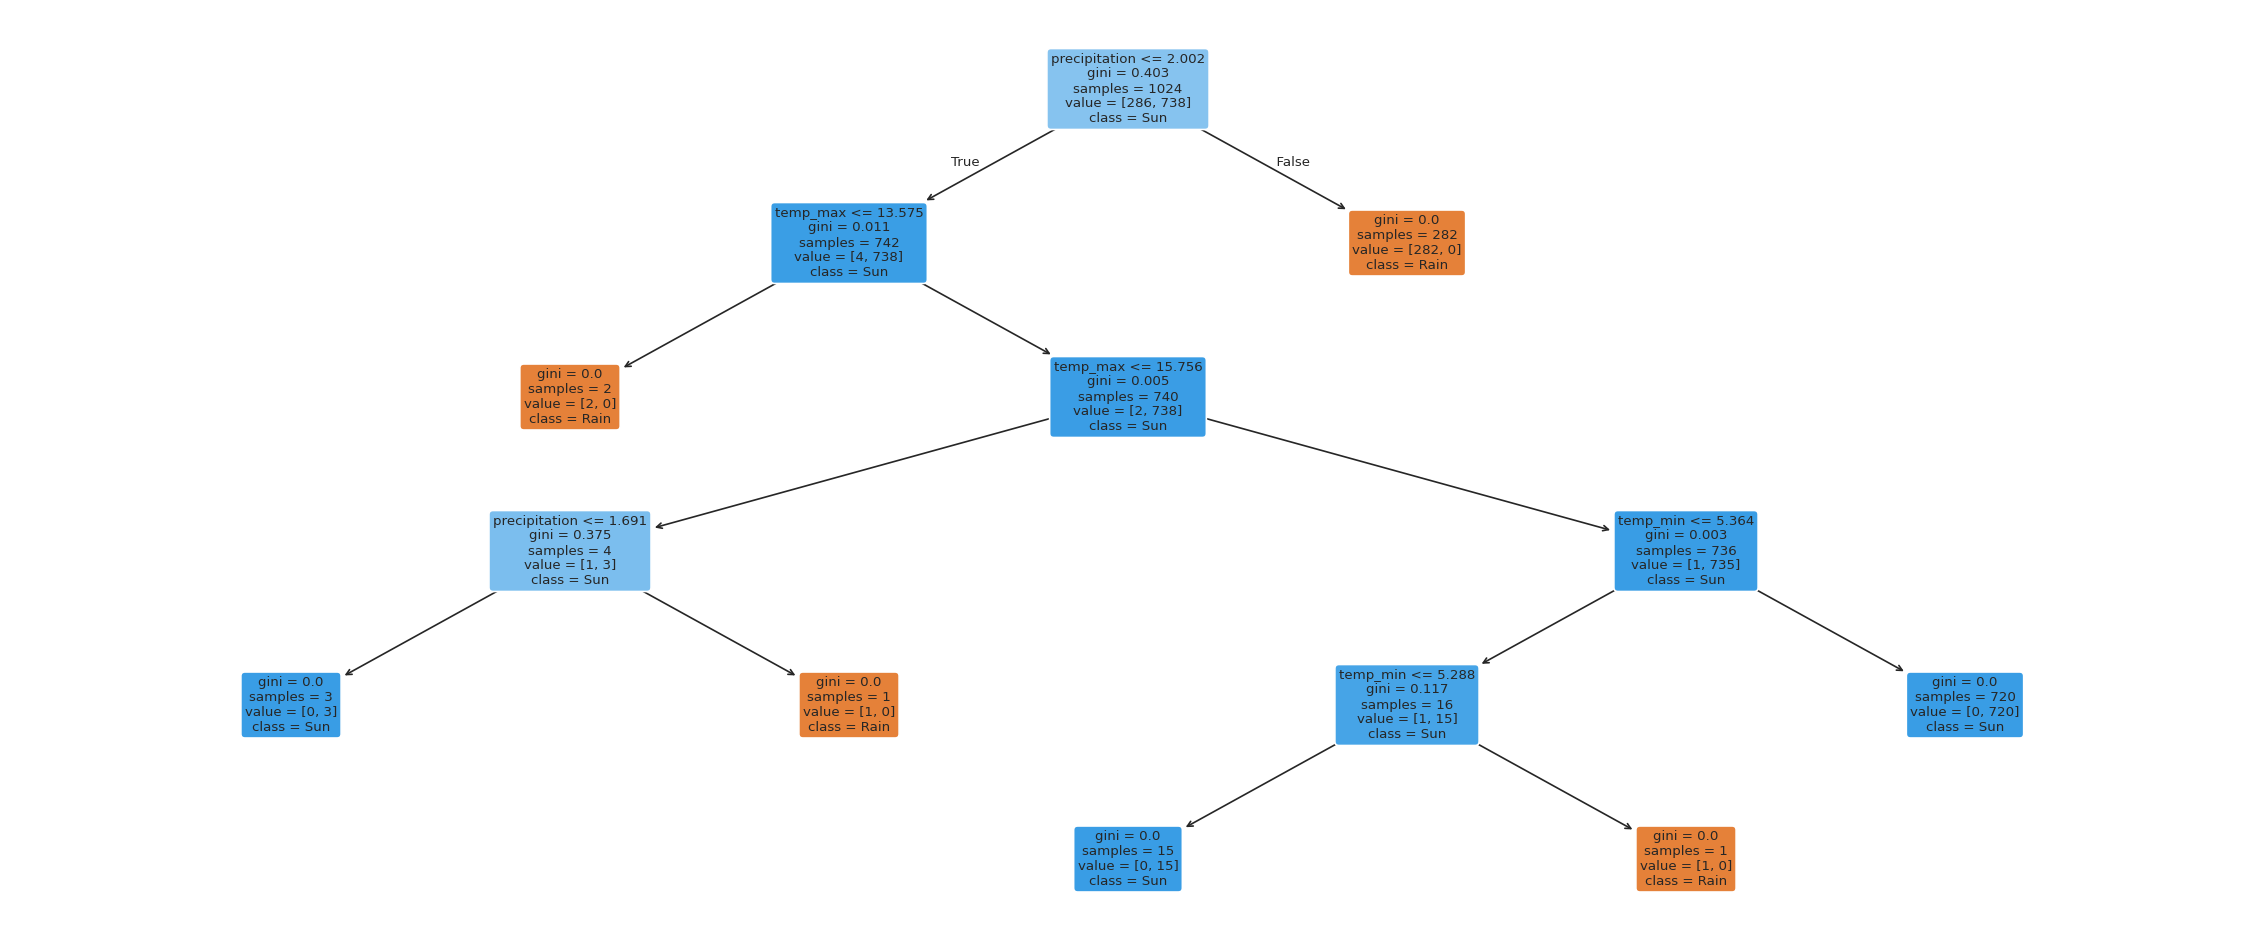

In [27]:
# Write code here:

plt.figure(figsize=(24, 10))
tree.plot_tree(clf,
               filled=True,
               class_names=["Rain", "Sun"],
               feature_names=X.columns.tolist(),
               fontsize=8,
               rounded=True)
plt.show()

---

# 3. Evaluation

**Accuracy alone is an insufficient metric**, particularly on imbalanced datasets. Consider: if 90% of samples are `sun`, a model that always predicts `sun` achieves 90% accuracy while being completely useless for detecting rain.

We will use three complementary tools:

| Metric | What it measures |
|---|---|
| **Accuracy** | Fraction of all predictions that are correct |
| **Confusion Matrix** | Breakdown of TP, FP, TN, FN for each class |
| **Classification Report** | Precision, Recall, F1-score per class |

Key formulas:

$$
\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

#### <font color="green">**Exercise 6: Evaluate the model**</font>

1. Use `clf.predict(X_test)` to generate predictions; store in `y_hat`.
2. Compute and print `accuracy_score(y_test, y_hat)`. Store it in `score`.
3. Compute the **confusion matrix** using `confusion_matrix(y_test, y_hat)` and plot it as a heatmap using `sns.heatmap()` with `annot=True`, `fmt='d'`, and axis labels `["Rain", "Sun"]`.
4. Print the **classification report** using `classification_report(y_test, y_hat, target_names=["Rain", "Sun"])`.

**Docs**:
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

Accuracy: 0.9922



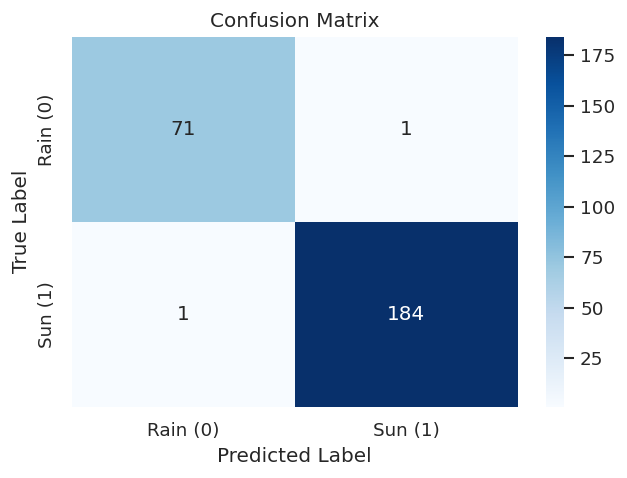


Classification Report:
              precision    recall  f1-score   support

        Rain       0.99      0.99      0.99        72
         Sun       0.99      0.99      0.99       185

    accuracy                           0.99       257
   macro avg       0.99      0.99      0.99       257
weighted avg       0.99      0.99      0.99       257



In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Step 1: Predict
y_hat = clf.predict(X_test)

# Step 2: Accuracy
score = accuracy_score(y_test, y_hat)
print(f"Accuracy: {score:.4f}\n")

# Step 3: Confusion matrix heatmap
cm = confusion_matrix(y_test, y_hat)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Rain (0)", "Sun (1)"],
            yticklabels=["Rain (0)", "Sun (1)"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_hat, target_names=["Rain", "Sun"]))

---

# 4. Model Analysis

Now that we have a working classifier, let's probe it more deeply.

#### <font color="green">**Exercise 7: Access particular node of the Decision Tree (Predict on custom inputs)**</font>

Use `clf.predict()` on the following two cases and interpret the results:

| | `precipitation` | `temp_max` | `temp_min` | `wind` |
|---|---|---|---|---|
| **Case 1** | 2 | 20 | 5 | 10 |
| **Case 2** | 0 | 20 | 5 | 1.1 |

Print the predicted class label (`rain` or `sun`) for each case.

> **Hint**: Wrap each case as a 2D NumPy array or a one-row DataFrame before calling `predict`.

In [29]:
# Wrap cases in a DataFrame so the model recognizes the feature names
case_1 = pd.DataFrame([[2, 20, 5, 10]], columns=X.columns)
case_2 = pd.DataFrame([[0, 20, 5, 1.1]], columns=X.columns)

prediction_1 = clf.predict(case_1)
prediction_2 = clf.predict(case_2)

# Decode: 0 -> 'rain', 1 -> 'sun'
label_map = {0: 'rain', 1: 'sun'}

print(f"Case 1: {label_map[prediction_1[0]]}")
print(f"Case 2: {label_map[prediction_2[0]]}")

Case 1: sun
Case 2: sun


<font color="green">**Your answer:**</font>
- Case 1: *(sun)*
- Case 2: *(sun)*

#### <font color="green">**Exercise 7.2: Feature Importances**</font>

After fitting, `clf.feature_importances_` gives the Gini-based importance of each feature (they sum to 1.0). Plot a horizontal bar chart of these importances, sorted from highest to lowest.

Which feature is the most important predictor? Does this match your intuition from the boxplots in Exercise 2.c?

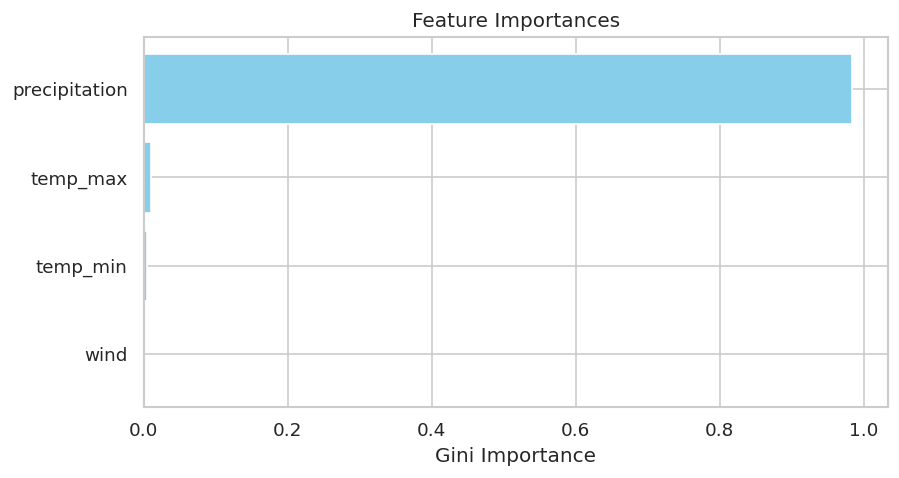

In [30]:
# Write code here:
importances = clf.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(8, 4))
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Gini Importance')
plt.title('Feature Importances')
plt.show()

**Your observation:** *Precipitation is heavily favoured as the most important feature. This aligns perfectly with the intuition from the boxplots, where precipitation was the clearest differentiator between sunny and rainy days.*

#### <font color="green">**Exercise 7.3 (Optional): Overfitting — Effect of `max_depth`**</font>

**Overfitting** occurs when a model memorises training data so precisely that it fails to generalise to unseen data.

1. Train a new `DecisionTreeClassifier` with **no** `max_depth` constraint (unlimited depth) and report both its train accuracy and test accuracy.
2. Then, train trees for `max_depth` in `[1, 2, 3, 4, 5, 6, 8, 10, None]`, recording train and test accuracy for each.
3. Plot train accuracy vs. test accuracy against `max_depth` on the same axes.

What do you observe? At what depth does the model start to overfit?

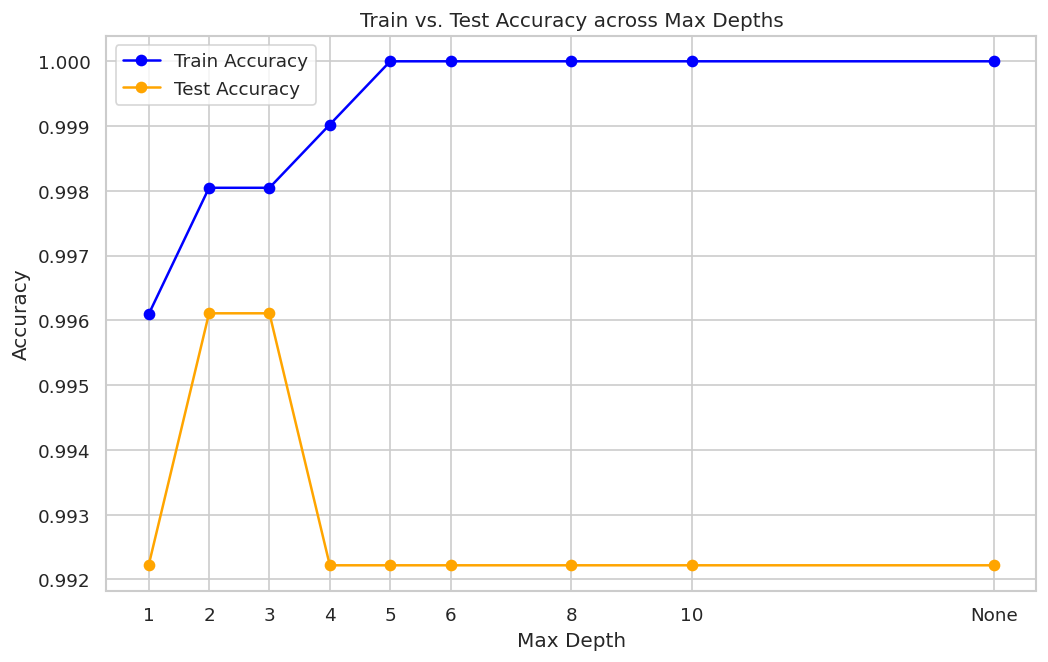

In [31]:
# Write code here:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_acc = []
test_acc = []

for d in depths:
    model = tree.DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

# Use a proxy value for 'None' on the x-axis for plotting
plot_depths = [d if d is not None else 15 for d in depths]

plt.figure(figsize=(10, 6))
plt.plot(plot_depths, train_acc, marker='o', label='Train Accuracy', color='blue')
plt.plot(plot_depths, test_acc, marker='o', label='Test Accuracy', color='orange')
plt.xticks(plot_depths, [str(d) for d in depths])
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy across Max Depths')
plt.legend()
plt.grid(True)
plt.show()

**Your answer:** *As max_depth increases, training accuracy continues to rise (approaching 100% when unrestricted). However, test accuracy peaks around a depth of 2 to 3 and then plateaus or drops. The divergence between the train and test curves demonstrates overfitting—the deep tree memorizes the noise in the training set but fails to generalize to the test set.*

> **Key insight:** An unconstrained tree fits the training data perfectly (train accuracy near 100%) but typically performs *worse* on the test set than a depth-limited tree. This gap between train and test accuracy is the empirical signature of overfitting. The `max_depth` hyperparameter controls the **bias-variance trade-off** — shallow trees underfit (high bias), deep trees overfit (high variance).

---

## Submission Checklist

Before submitting, confirm:

- [ ] All exercise cells are filled and produce output when run top-to-bottom (Kernel -> Restart & Run All).
- [ ] `random_state=42` is used consistently wherever required.
- [ ] Written observations are provided for Exercises 2.c, 7.2, and 7.3.
- [ ] All plots have axis labels and titles.

----

> **Submission:** Submit this notebook with all cells executed (output visible). Include your name at the top.

---

*Summer of Quant 2026 | Quant Club, IIT Kharagpur*